# Train DenseNet - Phân loại côn trùng

Notebook huấn luyện **DenseNet** (viết từ đầu, không dùng pretrained) trên tập dữ liệu côn trùng 13 lớp.

| Variant | Params | Block config | Growth rate |
|---|---|---|---|
| DenseNet-121 | ~7.0M | [6, 12, 24, 16] | 32 |
| DenseNet-169 | ~12.5M | [6, 12, 32, 32] | 32 |
| DenseNet-201 | ~18.1M | [6, 12, 48, 32] | 32 |

## 1. Mount Drive & Copy dữ liệu

## 2. Khám phá dữ liệu

/var/folders/hg/dtfsyvn54rs5tr074lnfrr7w0000gn/T/ipykernel_94293/56439642.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_counts, x="Split", y="Count", palette="viridis", ax=axes[0])
/var/folders/hg/dtfsyvn54rs5tr074lnfrr7w0000gn/T/ipykernel_94293/56439642.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count", palette="Set2", ax=axes[1])


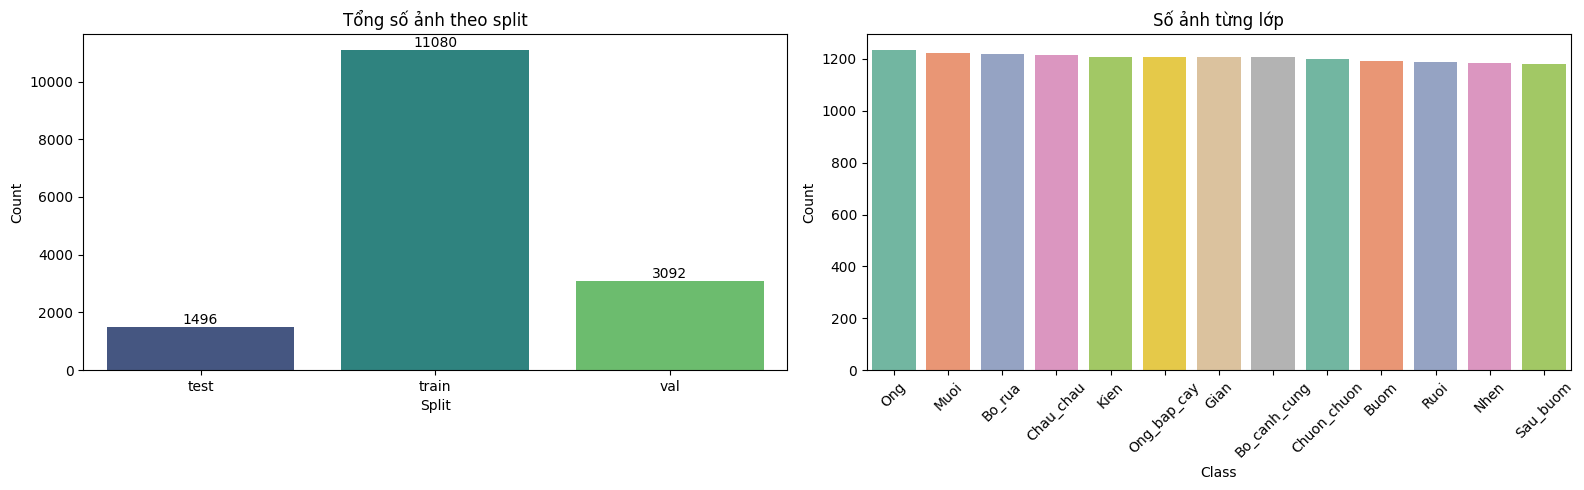

Split
test      1496
train    11080
val       3092


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

dataset_dir = "//Users/nguyenly/Desktop/code/XLA/data/dataset"
splits = ["train", "val", "test"]
data = []

for split in splits:
    split_dir = os.path.join(dataset_dir, split)
    if not os.path.exists(split_dir):
        continue
    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            n = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
            data.append({"Split": split, "Class": class_name, "Count": n})

df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

split_counts = df.groupby("Split")["Count"].sum().reset_index()
sns.barplot(data=split_counts, x="Split", y="Count", palette="viridis", ax=axes[0])
axes[0].set_title("Tổng số ảnh theo split")
for i, row in split_counts.iterrows():
    axes[0].text(i, row.Count, str(int(row.Count)), ha="center", va="bottom")

class_counts = df.groupby("Class")["Count"].sum().reset_index().sort_values("Count", ascending=False)
sns.barplot(data=class_counts, x="Class", y="Count", palette="Set2", ax=axes[1])
axes[1].set_title("Số ảnh từng lớp")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print(df.groupby("Split")["Count"].sum().to_string())

## 3. Setup & Import

In [2]:
import sys
import os

project_root = "/Users/nguyenly/Desktop/code/XLA"  # <-- sửa tên folder nếu cần
src_dir = os.path.join(project_root, "src")

assert os.path.exists(src_dir), f"Không tìm thấy: {src_dir}"

if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

os.chdir(project_root)
print("CWD:", os.getcwd())

import torch
import torch.nn as nn
import torch.optim as optim

from utils import config
from data.preprocess import get_dataloaders
from models.densenet import get_densenet121, get_densenet169, get_densenet201
from training.evaluate import evaluate_model
from utils.visualize import plot_training_history

print(f"Device  : {config.DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Epochs  : {config.EPOCHS}")
print(f"LR      : {config.LEARNING_RATE}")
print(f"Batch   : {config.BATCH_SIZE}")

CWD: /Users/nguyenly/Desktop/code/XLA
Device  : mps
PyTorch : 2.11.0
Epochs  : 70
LR      : 0.001
Batch   : 64


## 4. Load dữ liệu

In [3]:
train_loader, val_loader, test_loader, classes = get_dataloaders()

print(f"Số lớp  : {len(classes)}")
print(f"Classes : {classes}")
print(f"Train   : {len(train_loader)} batches ({len(train_loader.dataset)} ảnh)")
print(f"Val     : {len(val_loader)} batches ({len(val_loader.dataset)} ảnh)")
print(f"Test    : {len(test_loader)} batches ({len(test_loader.dataset)} ảnh)")

Loading data từ: /Users/nguyenly/Desktop/code/XLA/data
Số lớp  : 13
Classes : ['Bo_canh_cung', 'Bo_rua', 'Buom', 'Chau_chau', 'Chuon_chuon', 'Gian', 'Kien', 'Muoi', 'Nhen', 'Ong', 'Ong_bap_cay', 'Ruoi', 'Sau_buom']
Train   : 173 batches (11080 ảnh)
Val     : 49 batches (3092 ảnh)
Test    : 24 batches (1496 ảnh)


## 5. Khởi tạo mô hình

Đổi `MODEL_NAME` để chọn variant:
- `'densenet121'` — nhẹ nhất (~7M params), train nhanh
- `'densenet169'` — cân bằng (~12.5M params)
- `'densenet201'` — nặng nhất (~18M params), kết quả tốt nhất

In [4]:
MODEL_NAME = "densenet169"   # chọn: densenet121 | densenet169 | densenet201

_model_map = {
    "densenet121": get_densenet121,
    "densenet169": get_densenet169,
    "densenet201": get_densenet201,
}

if MODEL_NAME not in _model_map:
    raise ValueError(f"MODEL_NAME phải là một trong {list(_model_map.keys())}")

num_classes = len(classes)
model = _model_map[MODEL_NAME](num_classes=num_classes)
model = model.to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model         : {MODEL_NAME.upper()}")
print(f"Device        : {config.DEVICE}")
print(f"Tổng tham số  : {total_params:,}")
print(f"Tham số train : {train_params:,}")

Model         : DENSENET169
Device        : mps
Tổng tham số  : 12,506,125
Tham số train : 12,506,125


## 6. Cấu hình Optimizer & Scheduler

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.EPOCHS,
    eta_min=1e-5
)

models_saved_dir = os.path.join(project_root, "models_saved")
os.makedirs(models_saved_dir, exist_ok=True)
save_path = os.path.join(models_saved_dir, f"best_{MODEL_NAME}.pth")

print(f"Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print(f"Optimizer : SGD (lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)")
print(f"Scheduler : CosineAnnealingLR (T_max={config.EPOCHS}, eta_min=1e-5)")
print(f"Save path : {save_path}")

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : SGD (lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)
Scheduler : CosineAnnealingLR (T_max=70, eta_min=1e-5)
Save path : /Users/nguyenly/Desktop/code/XLA/models_saved/best_densenet169.pth


## 7. Huấn luyện

In [6]:
import time

best_val_loss = float("inf")
early_stop_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Bắt đầu huấn luyện [{MODEL_NAME.upper()}] trên {config.DEVICE.upper()}")
print(f"Train: {len(train_loader.dataset)} ảnh | Val: {len(val_loader.dataset)} ảnh")
print(f"Batches/epoch: {len(train_loader)}\n")

for epoch in range(1, config.EPOCHS + 1):
    print(f"Epoch {epoch}/{config.EPOCHS}")
    epoch_start = time.time()

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    n_batches = len(train_loader)

    for batch_idx, (inputs, labels) in enumerate(train_loader, 1):
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        bar_len = 30
        filled = int(bar_len * batch_idx / n_batches)
        bar = "=" * filled + ">" + "." * (bar_len - filled - 1) if filled < bar_len else "=" * bar_len
        elapsed_so_far = time.time() - epoch_start
        print(
            f"\r{batch_idx}/{n_batches} [{bar}] - "
            f"{elapsed_so_far:.0f}s - "
            f"loss: {running_loss/total:.4f} - acc: {correct/total:.4f}",
            end="", flush=True
        )

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= total
    val_acc   = correct / total
    elapsed = time.time() - epoch_start

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    bar = "=" * 30
    print(
        f"\r{n_batches}/{n_batches} [{bar}] - "
        f"{elapsed:.0f}s - "
        f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        prev = best_val_loss
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), save_path)
        tag = "inf" if prev == float("inf") else f"{prev:.4f}"
        print(f"   val_loss improved from {tag} to {val_loss:.4f}, saving → {os.path.basename(save_path)}")
    else:
        early_stop_counter += 1
        print(f"   val_loss did not improve from {best_val_loss:.4f} ({early_stop_counter}/{config.EARLY_STOPPING_PATIENCE})")
        if early_stop_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping tại epoch {epoch}!")
            break

print(f"\n=== HOÀN TẤT HUẤN LUYỆN ===")
print(f"Best val_loss : {best_val_loss:.4f}")
print(f"Model saved   : {save_path}")

Bắt đầu huấn luyện [DENSENET169] trên MPS
Train: 11080 ảnh | Val: 3092 ảnh
Batches/epoch: 173

Epoch 1/70


6/173 [=>............................] - 32s - loss: 2.5972 - acc: 0.0781

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


8/173 [=>............................] - 128s - loss: 2.5913 - acc: 0.0762

: 

## 8. Biểu đồ Loss & Accuracy

[✓] Đã lưu biểu đồ -> /Users/nguyenly/Desktop/code/XLA/models_saved/training_curve_densenet121.png


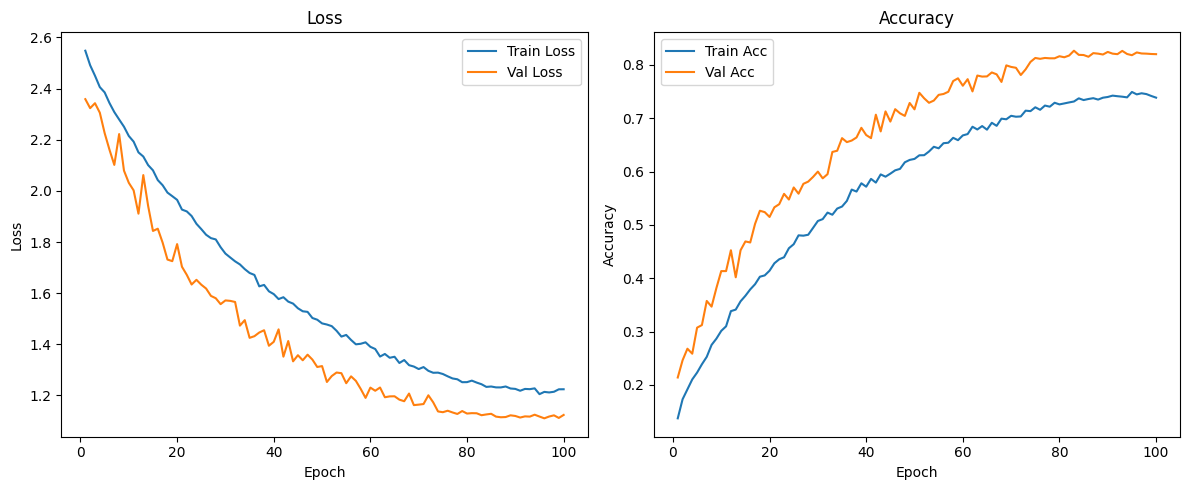

In [ ]:
plot_training_history(history, MODEL_NAME, models_saved_dir)

## 9. Đánh giá trên tập Test


[TEST] Accuracy: 0.8122 (1215/1496)
[✓] Đã lưu confusion matrix -> /Users/nguyenly/Desktop/code/XLA/models_saved/confusion_matrix.png


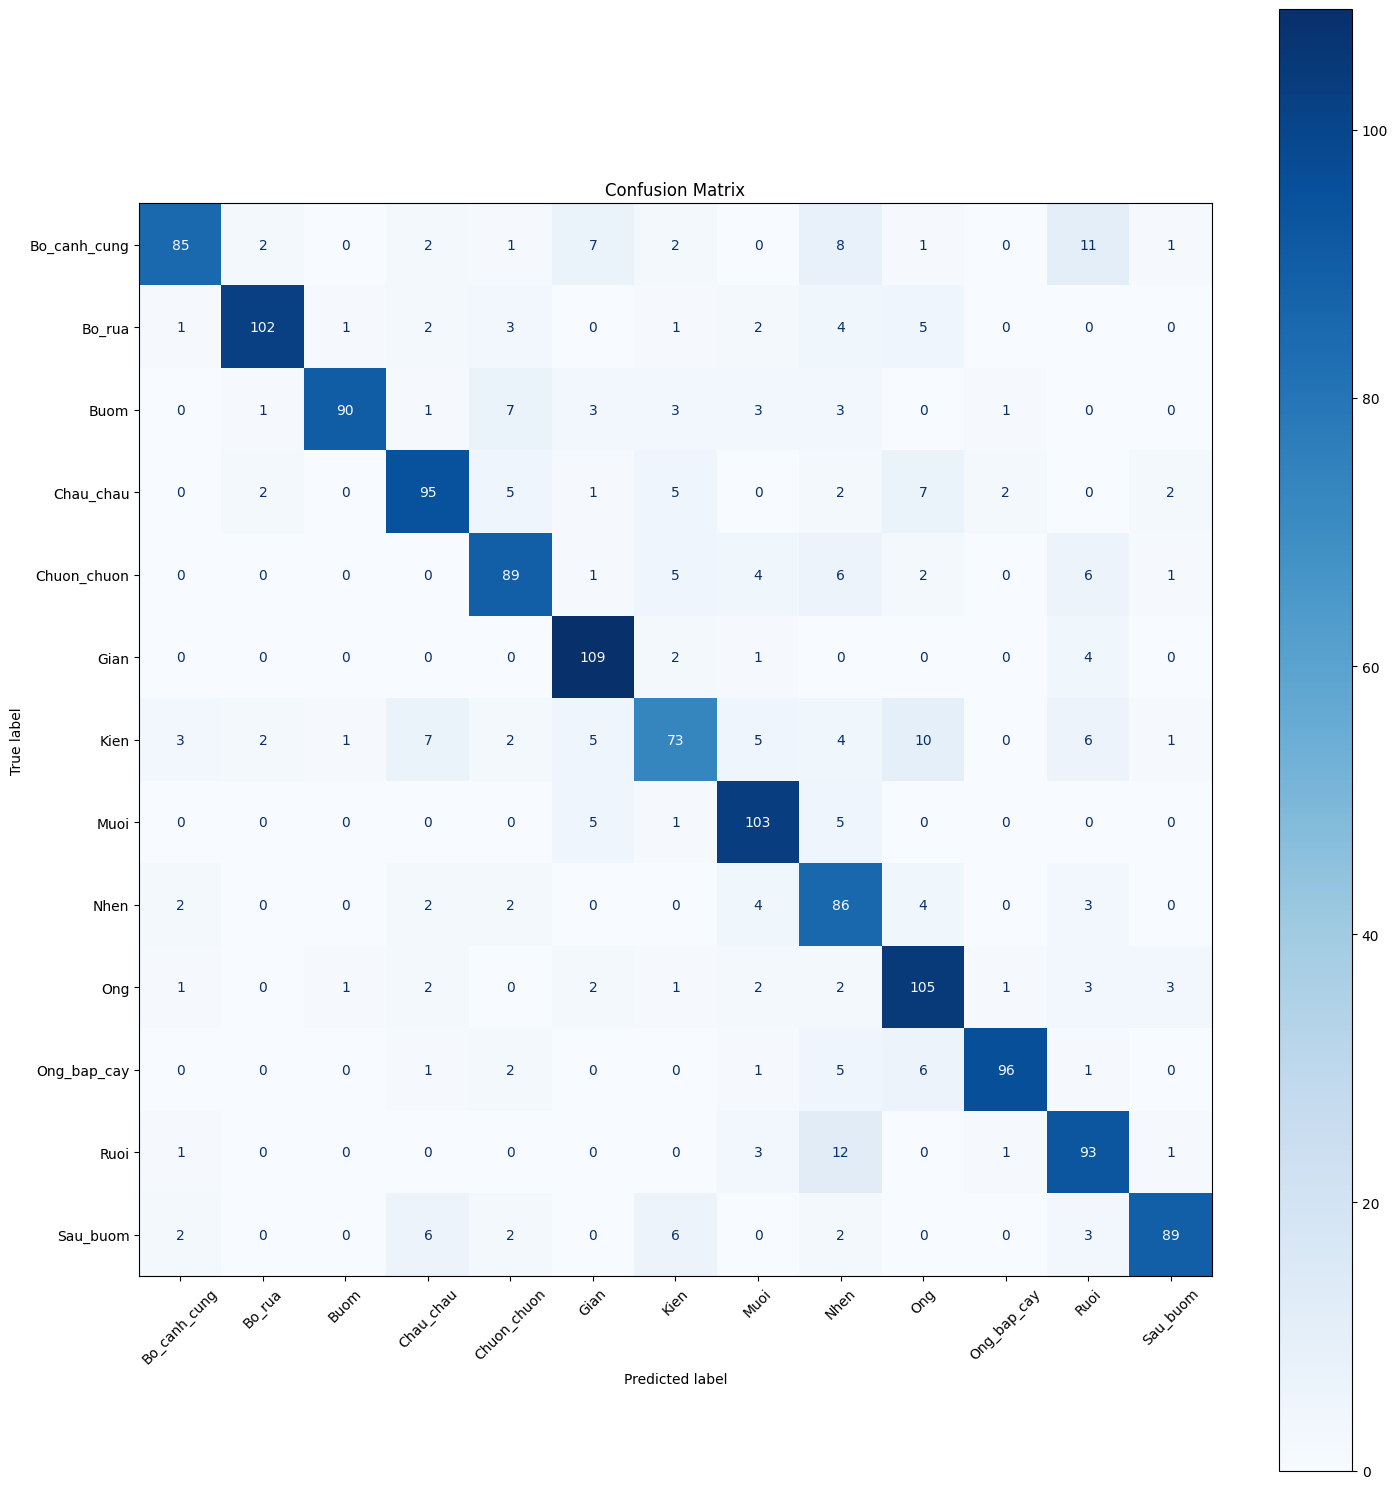

[✓] Đã lưu sample predictions -> /Users/nguyenly/Desktop/code/XLA/models_saved/sample_predictions.png


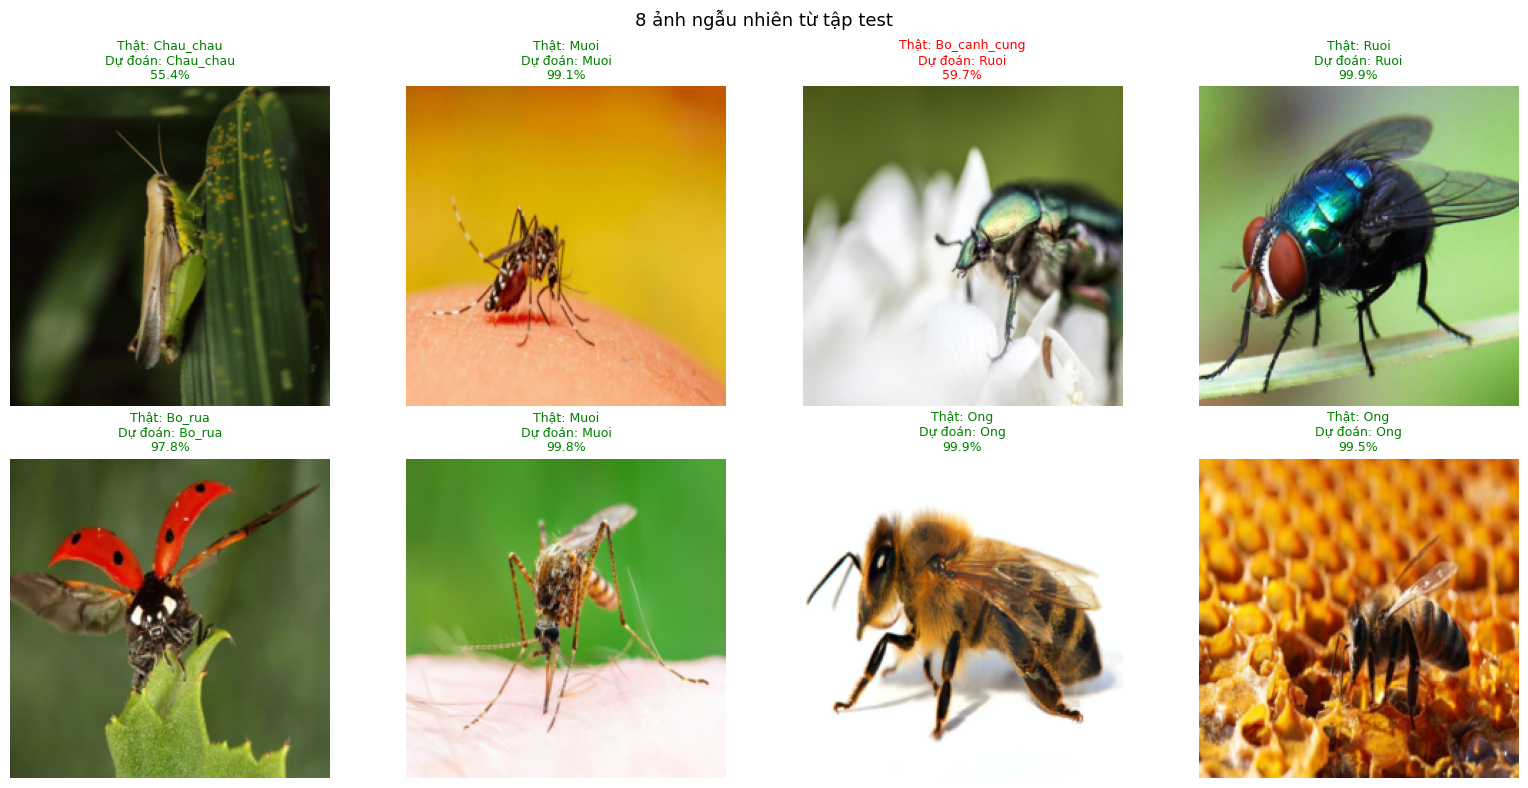

In [ ]:
model.load_state_dict(torch.load(save_path, map_location=config.DEVICE))
model = model.to(config.DEVICE)

evaluate_model(model, test_loader, test_loader.dataset, classes, models_saved_dir)

## 10. Confusion Matrix chi tiết

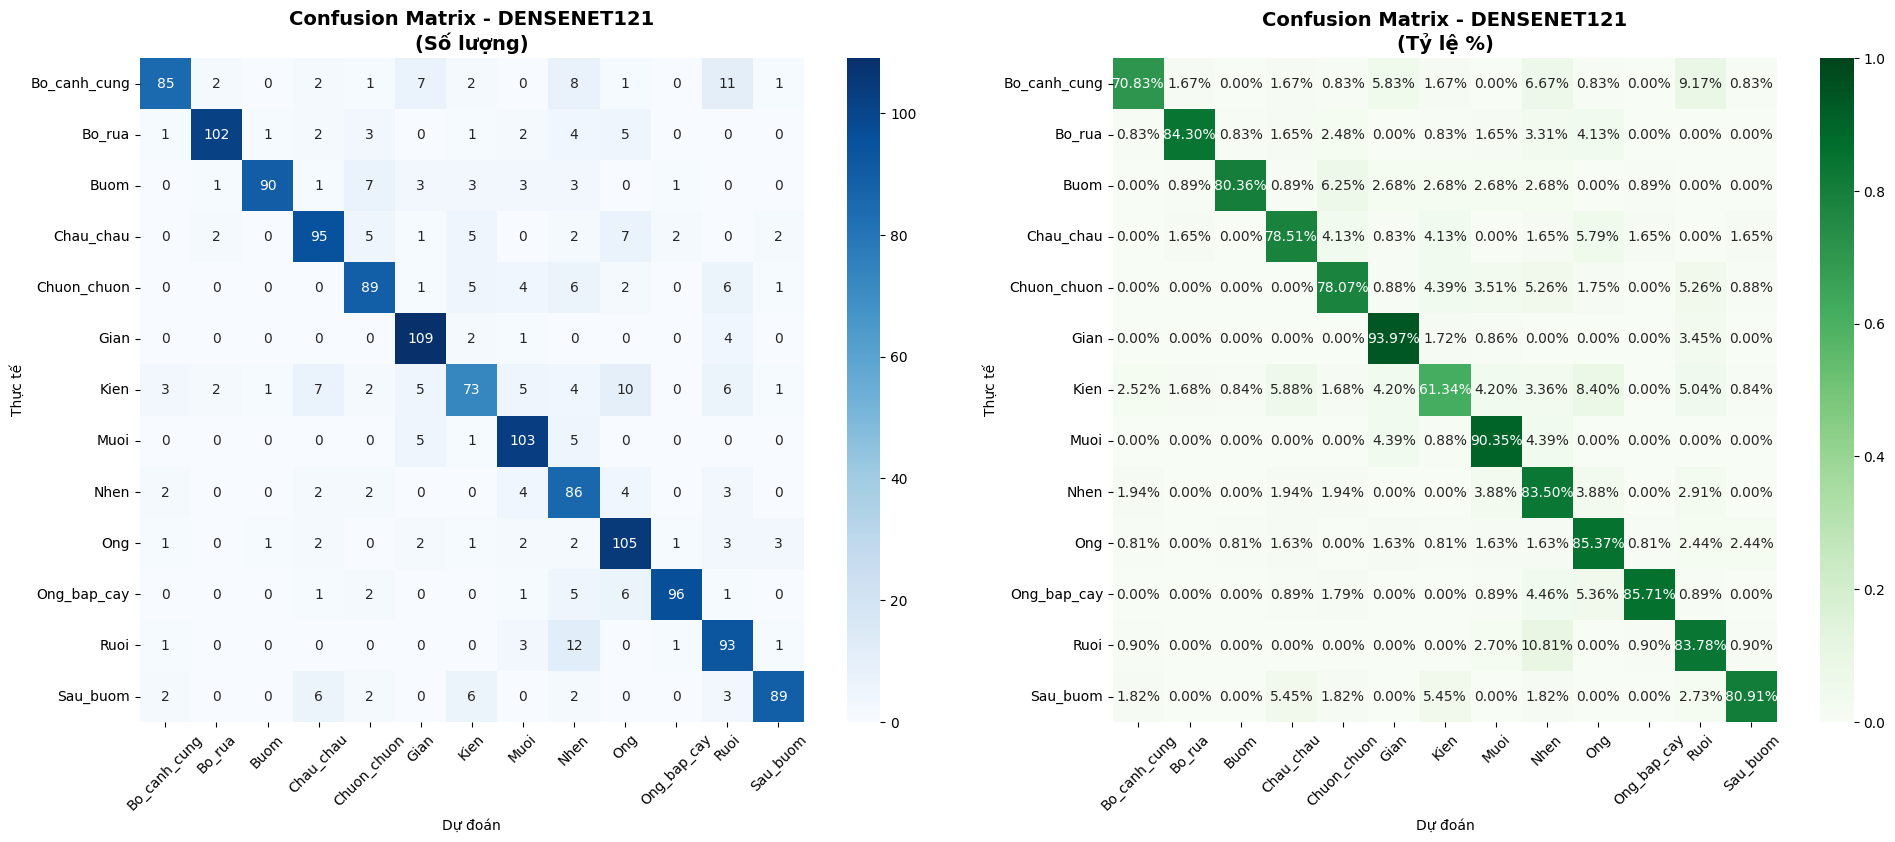

CLASSIFICATION REPORT - DENSENET121
              precision    recall  f1-score   support

Bo_canh_cung     0.8947    0.7083    0.7907       120
      Bo_rua     0.9358    0.8430    0.8870       121
        Buom     0.9677    0.8036    0.8780       112
   Chau_chau     0.8051    0.7851    0.7950       121
 Chuon_chuon     0.7876    0.7807    0.7841       114
        Gian     0.8195    0.9397    0.8755       116
        Kien     0.7374    0.6134    0.6697       119
        Muoi     0.8047    0.9035    0.8512       114
        Nhen     0.6187    0.8350    0.7107       103
         Ong     0.7500    0.8537    0.7985       123
 Ong_bap_cay     0.9505    0.8571    0.9014       112
        Ruoi     0.7154    0.8378    0.7718       111
    Sau_buom     0.9082    0.8091    0.8558       110

    accuracy                         0.8122      1496
   macro avg     0.8227    0.8131    0.8130      1496
weighted avg     0.8238    0.8122    0.8132      1496

Test Accuracy : 81.22%
Tổng mẫu test : 1496

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(config.DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            square=True, ax=axes[0], annot_kws={"size": 10})
axes[0].set_title(f"Confusion Matrix - {MODEL_NAME.upper()}\n(Số lượng)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dự đoán"); axes[0].set_ylabel("Thực tế")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens",
            xticklabels=classes, yticklabels=classes,
            square=True, ax=axes[1], annot_kws={"size": 10}, vmin=0, vmax=1)
axes[1].set_title(f"Confusion Matrix - {MODEL_NAME.upper()}\n(Tỷ lệ %)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Dự đoán"); axes[1].set_ylabel("Thực tế")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"confusion_matrix_{MODEL_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 70)
print(f"CLASSIFICATION REPORT - {MODEL_NAME.upper()}")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Tổng mẫu test : {len(all_labels)}")
print(f"Đúng          : {(all_preds == all_labels).sum()}")
print(f"Sai           : {(all_preds != all_labels).sum()}")

errors = [(classes[i], classes[j], cm[i][j])
          for i in range(len(classes)) for j in range(len(classes))
          if i != j and cm[i][j] > 0]
errors.sort(key=lambda x: x[2], reverse=True)
print("\nTOP 5 CẶP NHẦM LẪN NHIỀU NHẤT:")
for actual, predicted, count in errors[:5]:
    print(f"  {actual:20s} → {predicted:20s} : {count} lần")